In [ ]:
# notebook debugging preamble
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def wave(freq, phase, t):
    return np.cos(2 * np.pi * freq * t + phase)

In [291]:
import ipywidgets
from IPython.display import display

In [348]:
output = ipywidgets.Output()


def on_slider_change(change, var_name):
    globals()[var_name] = change["new"]
    with output:
        output.clear_output(wait=True)
        print(f"{var_name} changed to {change['new']}")


slider_equal = ipywidgets.IntSlider(
    value=10,
    min=10,
    max=50,
    step=10,
    description="equal",
)
slider_equal.observe(lambda change: on_slider_change(change, "equal"), names="value")
slider_less = ipywidgets.IntSlider(
    value=-5,
    min=-9,
    max=-1,
    step=1,
    description="less",
)
slider_less.observe(lambda change: on_slider_change(change, "less"), names="value")
slider_greater = ipywidgets.IntSlider(
    value=5,
    min=1,
    max=9,
    step=1,
    description="greater",
)
slider_greater.observe(
    lambda change: on_slider_change(change, "greater"), names="value"
)

In [349]:
display(ipywidgets.VBox([slider_equal, slider_less, slider_greater, output]))

In [342]:
duration = 20
period = 10
freq = 1 / period
sample_rate = 1000
t = np.linspace(0, duration, sample_rate * duration)
y = wave(freq, 0, t)

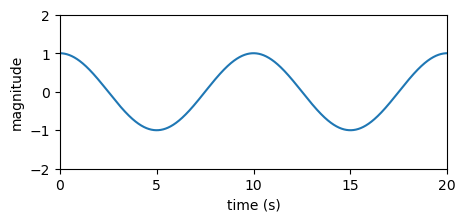

In [343]:
plt.figure(figsize=(5, 2))
plt.xlabel("time (s)")
plt.xlim(0, duration)
plt.xticks(np.arange(0, 21, 5))
plt.ylabel("magnitude")
plt.ylim(-2, 2)
plt.plot(t, y)

In [292]:
sampling_duration_equal_to_period = 100
sampling_duration_less_than_period = 98
sampling_duration_greater_than_period = 102
sampling_rate = 1

In [293]:
samples_equal_to_period = sampling_rate * sampling_duration_equal_to_period
samples_less_than_period = sampling_rate * sampling_duration_less_than_period
samples_greater_than_period = sampling_rate * sampling_duration_greater_than_period

In [294]:
t_equal_to_period = np.linspace(
    0, sampling_duration_equal_to_period - 1, samples_equal_to_period
)
t_less_than_period = np.linspace(
    0, sampling_duration_less_than_period - 1, samples_less_than_period
)
t_greater_than_period = np.linspace(
    0, sampling_duration_greater_than_period - 1, samples_greater_than_period
)

In [295]:
len(t_equal_to_period), len(t_less_than_period), len(t_greater_than_period)

(100, 98, 102)

In [296]:
t_equal_to_period, t_less_than_period, t_greater_than_period

(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
        52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
        65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
        78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.,
        91., 92., 93., 94., 95., 96., 97., 98., 99.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
        52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
        65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 7

In [297]:
y_equal_to_period = wave(freq, 0, t_equal_to_period)
y_less_than_period = wave(freq, 0, t_less_than_period)
y_greater_than_period = wave(freq, 0, t_greater_than_period)

In [298]:
import matplotlib.pyplot as plt


def plot_discrete_signal(time, signal):
    plt.figure(figsize=(5, 2))
    plt.xlabel("time (s)")
    plt.xlim(0, len(time) - 1)
    plt.xticks(np.arange(0, len(time), 1))
    plt.ylabel("magnitude")
    plt.ylim(-2, 2)
    markerline, stemline, baseline = plt.stem(
        time,
        signal,
        linefmt="-",
        markerfmt="o",
        basefmt="black",
    )
    markerline.set_markerfacecolor("none")
    plt.autoscale()
    plt.show()

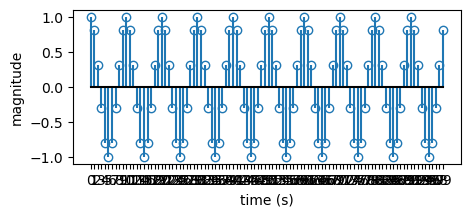

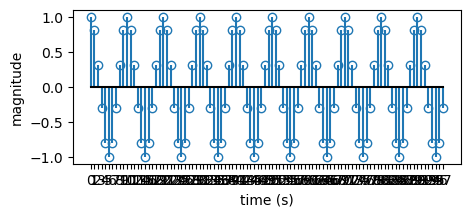

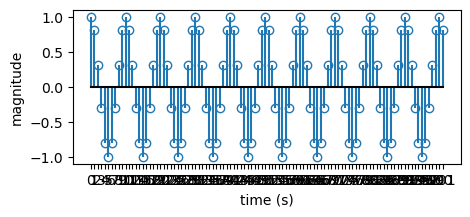

In [299]:
plot_discrete_signal(t_equal_to_period, y_equal_to_period)
plot_discrete_signal(t_less_than_period, y_less_than_period)
plot_discrete_signal(t_greater_than_period, y_greater_than_period)

In [300]:
fft_equal_to_period = np.fft.fft(y_equal_to_period)[: samples_equal_to_period // 2]
fft_less_than_period = np.fft.fft(y_less_than_period)[: samples_less_than_period // 2]
fft_greater_than_period = np.fft.fft(y_greater_than_period)[
    : samples_greater_than_period // 2
]

In [301]:
def normalizing(x: np.array):
    norm = np.abs(x).sum()
    th = norm * 0.01
    small_idx_real = np.where(np.abs(x.real) < th)
    x.real[small_idx_real] = 0
    small_idx_imag = np.where(np.abs(x.imag) < th)
    x.imag[small_idx_imag] = 0
    return x

In [302]:
fft_equal_to_period = normalizing(fft_equal_to_period)
fft_less_than_period = normalizing(fft_less_than_period)
fft_greater_than_period = normalizing(fft_greater_than_period)

In [303]:
magnitude_spectrum_equal_to_period = np.abs(fft_equal_to_period)
magnitude_spectrum_less_than_period = np.abs(fft_less_than_period)
magnitude_spectrum_greater_than_period = np.abs(fft_greater_than_period)

In [304]:
def maximum_normalization(x):
    return x / np.max(x)

In [305]:
magnitude_spectrum_equal_to_period = maximum_normalization(
    magnitude_spectrum_equal_to_period
)
magnitude_spectrum_less_than_period = maximum_normalization(
    magnitude_spectrum_less_than_period
)
magnitude_spectrum_greater_than_period = maximum_normalization(
    magnitude_spectrum_greater_than_period
)

In [306]:
f_equal_to_period = np.fft.fftfreq(len(t_equal_to_period), d=1 / sampling_rate)[
    : samples_equal_to_period // 2
]
f_less_than_period = np.fft.fftfreq(len(t_less_than_period), d=1 / sampling_rate)[
    : samples_less_than_period // 2
]
f_greater_than_period = np.fft.fftfreq(len(t_greater_than_period), d=1 / sampling_rate)[
    : samples_greater_than_period // 2
]

In [307]:
phase_spectrum_equal_to_period = np.angle(fft_equal_to_period, deg=True)
phase_spectrum_less_than_period = np.angle(fft_less_than_period, deg=True)
phase_spectrum_greater_than_period = np.angle(fft_greater_than_period, deg=True)

In [308]:
import matplotlib.pyplot as plt


def plot_magnitude_spectrum(freq_bins, spectrum):
    plt.figure(figsize=(5, 2))
    plt.xlabel("Frequency (Hz)")
    plt.xlim(0, max(freq_bins))
    plt.xticks(freq_bins)
    plt.ylabel("Magnitude")
    plt.ylim(bottom=0)
    plt.yticks(np.arange(0, 1.2 + 0.2, 0.4))
    markerline, stemline, baseline = plt.stem(
        freq_bins,
        spectrum,
        linefmt="r-",
        markerfmt="o",
        basefmt="black",
    )
    markerline.set_markerfacecolor("none")
    baseline.set_lw(1)
    # plt.autoscale()
    plt.show()

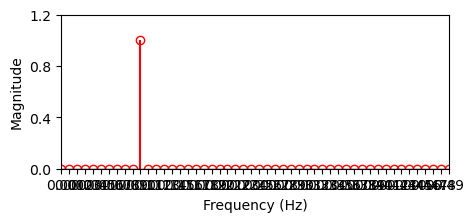

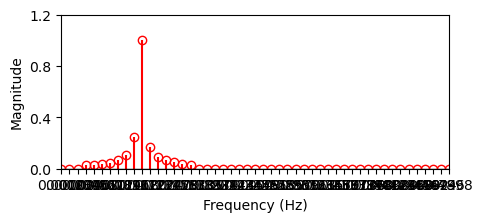

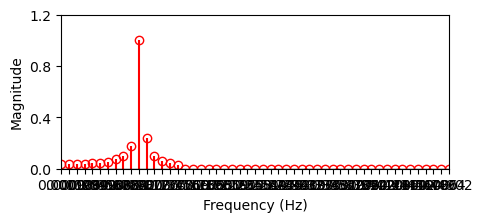

In [309]:
plot_magnitude_spectrum(f_equal_to_period, magnitude_spectrum_equal_to_period)
plot_magnitude_spectrum(f_less_than_period, magnitude_spectrum_less_than_period)
plot_magnitude_spectrum(f_greater_than_period, magnitude_spectrum_greater_than_period)

In [310]:
import matplotlib.pyplot as plt


def plot_phase_spectrum(freq_bins, phase_spectrum, deg=False):
    plt.figure(figsize=(5, 2))
    plt.xlabel("Frequency (Hz)")
    plt.xlim(0, max(freq_bins))
    plt.xticks(freq_bins)
    if deg:
        plt.ylabel("Phase (degrees)")
        plt.ylim(-180, 180)
        plt.yticks(np.arange(-180, 181, 90))
    else:
        plt.ylabel("Phase (radians)")
        plt.ylim(-np.pi, np.pi)
        plt.yticks(np.arange(-np.pi, np.pi + 1, 1))
    markerline, stemline, baseline = plt.stem(
        freq_bins,
        phase_spectrum,
        linefmt="g-",
        markerfmt="o",
        basefmt="black",
    )
    markerline.set_markerfacecolor("none")
    markerline.set_zorder(3)
    baseline.set_lw(1)
    plt.show()

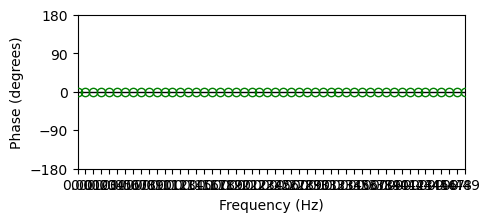

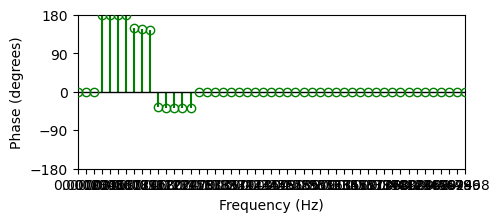

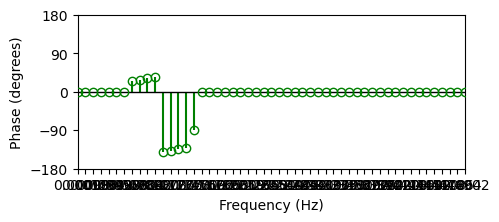

In [311]:
plot_phase_spectrum(f_equal_to_period, phase_spectrum_equal_to_period, deg=True)
plot_phase_spectrum(f_less_than_period, phase_spectrum_less_than_period, deg=True)
plot_phase_spectrum(f_greater_than_period, phase_spectrum_greater_than_period, deg=True)

In [313]:
def polar_to_cartesian(magnitude, phase, deg=False):
    if deg:
        phase = np.deg2rad(phase)
    return magnitude * np.exp(1j * phase)

In [312]:
def cartesian_to_polar(x, deg=False):
    return np.abs(x), np.angle(x, deg=deg)